<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/Attention_and_Transformers_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Explore aqui os mecanismos de Atenção e Transformers**

# Atenção

In [114]:
import tensorflow as tf
import numpy as np

# 1. Definir a camada de Self-Attention
class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super(SelfAttention, self).__init__()
        self.d_model = d_model
        # Camadas lineares para projetar a entrada em Q, K e V
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

    def call(self, x):
        # x é a entrada (batch_size, seq_len, d_model)

        # 1. Projeção em Q, K, V
        q = self.wq(x)  # (batch_size, seq_len, d_model)
        k = self.wk(x)  # (batch_size, seq_len, d_model)
        v = self.wv(x)  # (batch_size, seq_len, d_model)

        # 2. Cálculo da Pontuação de Atenção (Q * K^T)
        # Transpõe K para (batch_size, d_model, seq_len)
        matmul_qk = tf.matmul(q, k, transpose_b=True)  # (batch_size, seq_len, seq_len)

        # 3. Escalonamento (Scaled Dot-Product Attention)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        # 4. Softmax para obter os Pesos de Atenção
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (batch_size, seq_len, seq_len)

        # 5. Ponderação dos Valores (Attention Weights * V)
        output = tf.matmul(attention_weights, v)  # (batch_size, seq_len, d_model)

        return output, attention_weights

# 2. Exemplo de Uso
# Configurações
d_model = 64  # Dimensão do modelo (embeddings)
seq_len = 10  # Comprimento da sequência
batch_size = 1

# Criar uma entrada de exemplo (simulando embeddings de 10 palavras)
# Cada palavra é representada por um vetor de 64 dimensões
input_data = tf.random.uniform((batch_size, seq_len, d_model))

# Instanciar e chamar a camada de Self-Attention
attention_layer = SelfAttention(d_model)
output, weights = attention_layer(input_data)

print(f"Formato da Entrada (Embeddings): {input_data.shape}")
print(f"Formato da Saída (Contextualizada): {output.shape}")
print(f"Formato dos Pesos de Atenção: {weights.shape}")

# Análise dos Pesos de Atenção (para a primeira e única sequência do batch)
# weights[0] é uma matriz 10x10. A linha 'i' mostra o quanto a palavra 'i' prestou atenção nas outras 10 palavras.
print("\nPesos de Atenção (Primeira Sequência):")
print(weights[0].numpy().round(3))

# Exemplo de como a primeira palavra (índice 0) se relaciona com as outras:
print(f"\nAtenção da primeira palavra nas outras: {weights[0][0].numpy().round(3)}")

Formato da Entrada (Embeddings): (1, 10, 64)
Formato da Saída (Contextualizada): (1, 10, 64)
Formato dos Pesos de Atenção: (1, 10, 10)

Pesos de Atenção (Primeira Sequência):
[[0.092 0.108 0.102 0.089 0.109 0.115 0.087 0.111 0.097 0.09 ]
 [0.094 0.099 0.107 0.084 0.111 0.118 0.093 0.097 0.093 0.104]
 [0.088 0.095 0.1   0.096 0.123 0.108 0.088 0.102 0.095 0.103]
 [0.085 0.109 0.119 0.09  0.101 0.119 0.098 0.098 0.085 0.095]
 [0.087 0.105 0.108 0.084 0.105 0.117 0.085 0.113 0.107 0.089]
 [0.084 0.102 0.12  0.091 0.095 0.109 0.099 0.105 0.089 0.106]
 [0.096 0.102 0.096 0.079 0.103 0.109 0.089 0.104 0.104 0.117]
 [0.085 0.092 0.117 0.089 0.11  0.127 0.09  0.104 0.086 0.101]
 [0.086 0.102 0.118 0.099 0.1   0.12  0.086 0.101 0.087 0.102]
 [0.098 0.103 0.121 0.081 0.101 0.115 0.092 0.097 0.087 0.105]]

Atenção da primeira palavra nas outras: [0.092 0.108 0.102 0.089 0.109 0.115 0.087 0.111 0.097 0.09 ]


In [115]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization
import numpy as np

# 1. Camada de Codificação Posicional (Positional Encoding)
def get_angles(pos, i, d_model):
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    return pos * angle_rates

def positional_encoding(position, d_model):
    angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                            np.arange(d_model)[np.newaxis, :],
                            d_model)

    # Aplica sin a índices pares na dimensão do modelo
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # Aplica cos a índices ímpares na dimensão do modelo
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)

# 2. Camada de Multi-Head Attention (Simplificada)
class MultiHeadAttention(Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        self.depth = d_model // self.num_heads

        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)

        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        # Divide o último eixo em (num_heads, depth)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        # Transpõe o resultado para (batch_size, num_heads, seq_len, depth)
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)  # (batch_size, seq_len, d_model)
        k = self.wk(k)  # (batch_size, seq_len, d_model)
        v = self.wv(v)  # (batch_size, seq_len, d_model)

        q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
        v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

        # Scaled Dot-Product Attention
        matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth)

        # Concatenação das cabeças
        output = tf.transpose(output, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)
        concat_attention = tf.reshape(output, (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

        # Camada final
        output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)

        return output, attention_weights

# 3. Bloco do Encoder (Encoder Layer)
class EncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(EncoderLayer, self).__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),  # dff é a dimensão interna da FFN
            Dense(d_model)
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)

        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training):
        # 1. Sub-camada de Multi-Head Attention (Self-Attention)
        attn_output, _ = self.mha(x, x, x)  # Q=K=V=x
        attn_output = self.dropout1(attn_output, training=training)
        # Adição e Normalização (Residual Connection + Layer Norm)
        out1 = self.layernorm1(x + attn_output)  # (batch_size, input_seq_len, d_model)

        # 2. Sub-camada Feed Forward
        ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
        ffn_output = self.dropout2(ffn_output, training=training)
        # Adição e Normalização (Residual Connection + Layer Norm)
        out2 = self.layernorm2(out1 + ffn_output)  # (batch_size, input_seq_len, d_model)

        return out2

# 4. Exemplo de Uso do Bloco Encoder
# Configurações
d_model = 128
num_heads = 4
dff = 512
seq_len = 20
batch_size = 1

# Criar uma entrada de exemplo (simulando embeddings de 20 palavras)
input_embedding = tf.random.uniform((batch_size, seq_len, d_model))

# Adicionar Positional Encoding
pos_encoding_layer = positional_encoding(seq_len, d_model)
input_with_pos = input_embedding + pos_encoding_layer[:, :seq_len, :]

# Instanciar e chamar o Bloco Encoder
encoder_layer = EncoderLayer(d_model, num_heads, dff)
encoder_output = encoder_layer(input_with_pos, training=False)

print(f"Formato da Entrada (Embeddings + Positional Encoding): {input_with_pos.shape}")
print(f"Formato da Saída do Bloco Encoder: {encoder_output.shape}")

Formato da Entrada (Embeddings + Positional Encoding): (1, 20, 128)
Formato da Saída do Bloco Encoder: (1, 20, 128)


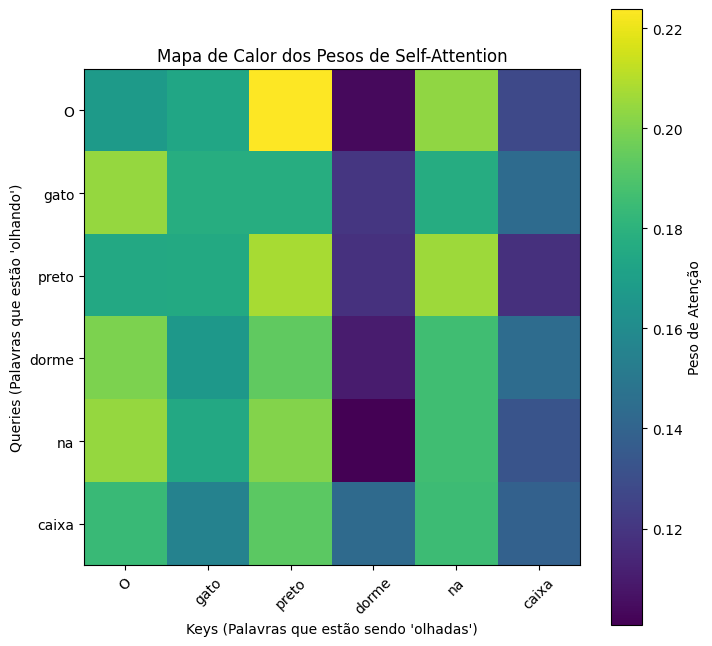

Matriz de Pesos de Atenção (Linha = Query, Coluna = Key):
[[0.168 0.173 0.224 0.104 0.203 0.128]
 [0.204 0.178 0.177 0.12  0.177 0.144]
 [0.175 0.175 0.208 0.118 0.206 0.118]
 [0.2   0.166 0.194 0.11  0.186 0.144]
 [0.204 0.175 0.201 0.101 0.186 0.133]
 [0.184 0.155 0.193 0.143 0.185 0.139]]


In [116]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir a camada de Self-Attention (Revisada para aceitar entrada de texto)
class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super(SelfAttention, self).__init__()
        self.d_model = d_model
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

    def call(self, x):
        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)

        return output, attention_weights

# 2. Exemplo de Uso com Simulação de Embeddings de Texto
# Frase de exemplo
sentence = "O gato preto dorme na caixa"
# sentence = "O gato perseguiu o rato porque ele estava com fome"
words = sentence.split()
seq_len = len(words)
d_model = 64

# Simular embeddings (vetores aleatórios para cada palavra)
# Em um modelo real, estes seriam embeddings aprendidos
word_embeddings = tf.random.uniform((1, seq_len, d_model))

# Instanciar e chamar a camada de Self-Attention
attention_layer = SelfAttention(d_model)
_, weights = attention_layer(word_embeddings)

# 3. Visualização dos Pesos de Atenção
attention_matrix = weights[0].numpy() # Pega a matriz de atenção para a primeira (e única) sequência

plt.figure(figsize=(8, 8))
plt.imshow(attention_matrix, cmap='viridis')
plt.xticks(ticks=np.arange(seq_len), labels=words, rotation=45)
plt.yticks(ticks=np.arange(seq_len), labels=words)
plt.xlabel("Keys (Palavras que estão sendo 'olhadas')")
plt.ylabel("Queries (Palavras que estão 'olhando')")
plt.title("Mapa de Calor dos Pesos de Self-Attention")
plt.colorbar(label='Peso de Atenção')
plt.show()

print("Matriz de Pesos de Atenção (Linha = Query, Coluna = Key):")
print(attention_matrix.round(3))

# Token $\times$ Token Embeddings


In [120]:
%%script echo off

Texto:        "Computadores são incríveis!"
↓
Tokenização:  ['Comput', 'adores', ' são', ' incríveis', '!']
↓
IDs:          [9223, 28656, 602, 36309, 0]
↓
Embeddings:   [[0.02, -0.11, ..., 0.34],  # vetor de 768 dims
                ...
               [0.15,  0.07, ..., -0.05]]
↓
Positional encoding adicionado → entrada do Transformer


off


In [4]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")

texto = "Computadores são incríveis!"
tokens = tokenizer.tokenize(texto)
ids = tokenizer.encode(texto)

print("Tokens:", tokens)
print("IDs:", ids)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Tokens: ['Com', 'put', 'ad', 'ores', 'Ġs', 'Ã£o', 'Ġinc', 'r', 'ÃŃ', 've', 'is', '!']
IDs: [5377, 1996, 324, 2850, 264, 28749, 753, 81, 8836, 303, 271, 0]


O tamanho do vocabulário do GPT-2 base é de 50257 (1024 no GPT-2 medium etc.).

In [119]:
vocab = tokenizer.get_vocab()
len(vocab)

50257

Para cada token há um embedding de tamanho 768 (GPT-2).

In [6]:
import torch
from transformers import GPT2Model

model = GPT2Model.from_pretrained("distilgpt2")

input_ids = torch.tensor([ids])  # [1, seq_len]
embeddings = model.wte(input_ids)  # "word token embeddings"

print(embeddings.shape)


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

torch.Size([1, 12, 768])


In [7]:
prompt1 = "Olá Mundo"
print(tokenizer.tokenize(prompt1))
embeddings1 = model.wte(torch.tensor([tokenizer.encode(tokenizer.tokenize(prompt1))]))
print(embeddings1.shape)
print()

prompt2 = "Olá Mundo como vai?"
print(tokenizer.tokenize(prompt2))
embeddings2 = model.wte(torch.tensor([tokenizer.encode(tokenizer.tokenize(prompt2))]))
print(embeddings2.shape)


['Ol', 'Ã¡', 'ĠMund', 'o']
torch.Size([1, 4, 768])

['Ol', 'Ã¡', 'ĠMund', 'o', 'Ġcom', 'o', 'Ġv', 'ai', '?']
torch.Size([1, 9, 768])


In [13]:
display(embeddings1[0, :, :5])
display(embeddings2[0, :, :5])

tensor([[ 2.0054e-02, -4.1189e-03,  1.6798e-01, -5.9721e-02, -4.1018e-02],
        [ 3.2477e-03, -1.3205e-01,  1.4465e-01, -1.4118e-01,  1.3668e-01],
        [ 1.3656e-04, -1.1144e-01, -1.1762e-02, -8.0518e-03,  1.7822e-01],
        [-1.2048e-01,  3.0588e-02,  2.3356e-01, -3.9442e-02,  9.8987e-02]],
       grad_fn=<SliceBackward0>)

tensor([[ 2.0054e-02, -4.1189e-03,  1.6798e-01, -5.9721e-02, -4.1018e-02],
        [ 3.2477e-03, -1.3205e-01,  1.4465e-01, -1.4118e-01,  1.3668e-01],
        [ 1.3656e-04, -1.1144e-01, -1.1762e-02, -8.0518e-03,  1.7822e-01],
        [-1.2048e-01,  3.0588e-02,  2.3356e-01, -3.9442e-02,  9.8987e-02],
        [ 6.5780e-02, -7.2587e-02, -5.0808e-02,  1.1403e-01,  3.5896e-02],
        [-1.2048e-01,  3.0588e-02,  2.3356e-01, -3.9442e-02,  9.8987e-02],
        [ 6.2854e-02, -1.2996e-01,  7.9297e-02,  1.9473e-01,  1.4558e-01],
        [-2.1511e-01, -5.5607e-03,  9.8705e-02, -2.8026e-01,  4.8092e-03],
        [-1.0522e-01, -5.6401e-02,  2.9142e-02,  1.3502e-01,  1.0679e-01]],
       grad_fn=<SliceBackward0>)

In [16]:
embeddings1[0, 1, :5] == embeddings2[0, 1, :5]

tensor([True, True, True, True, True])

## Tamanhos da Representação dos Modelos

| Modelo       | Camadas (L) | Cabeças de atenção | Dimensão (d_model) | Parâmetros |
| :----------- | :---------: | :----------------: | :----------------: | :--------: |
| GPT-2 small  |      12     |         12         |       **768**      |    117M    |
| GPT-2 medium |      24     |         16         |        1024        |    345M    |
| GPT-2 large  |      36     |         20         |        1280        |    774M    |
| GPT-2 XL     |      48     |         25         |        1600        |    1.5B    |


## Tokens e o Aprendizado de Máquina

As representação de mensagens, assim como vimos no word embedding, são representações de tamanho variável.

| Frase      | nº tokens | Tensor resultante |
| :--------- | :-------: | :---------------: |
| Mensagem 0 |     25    |    `[25, 768]`    |
| Mensagem 1 |    120    |    `[120, 768]`   |
| ...        |    ...    |    ...            |
| Mensagem n |    537   |    `[537, 768]`   |


### **Com Transformers**

O mecanismo de "self-attention" considera o contexto de todos os tokens da sequência. A única restrição é um tamanho máximo de contexto, como 1024 tokens no GPT-2 small.

### **Como Modelos Tradicionais de ML (SVM, XGBoost, RandomForest...)**

| Método                            | Descrição                                              | Dimensão resultante |
| :-------------------------------- | :----------------------------------------------------- | :-----------------: |
| **[CLS] token** (BERT-like)       | Usa o embedding do primeiro token como resumo da frase |         768         |
| **Mean pooling**                  | Média dos embeddings de todos os tokens                |         768         |
| **Max pooling**                   | Maior valor em cada dimensão ao longo dos tokens       |         768         |
| **Attention pooling**             | Combina tokens com pesos aprendidos                    |         768         |
| **Última camada oculta do GPT-2** | Média ou último estado                                 |         768         |


Por exemplo com o GPT-2,

In [17]:
text = '''Porque se chamavam homens
Também se chamavam sonhos
E sonhos não envelhecem
'''

inputs = tokenizer(text, return_tensors="pt")

outputs = model(**inputs)
last_hidden_state = outputs.last_hidden_state  # [1, seq_len, 768]
sentence_embedding = last_hidden_state.mean(dim=1)  # [1, 768]

print(sentence_embedding.shape)


torch.Size([1, 768])


e o BERT,

In [19]:
from transformers import BertTokenizer, TFBertModel

tokenizer1 = BertTokenizer.from_pretrained('neuralmind/bert-large-portuguese-cased')
model1 = TFBertModel.from_pretrained('neuralmind/bert-large-portuguese-cased', from_pt=True)

inputs = tokenizer(text, return_tensors="pt")

outputs = model(**inputs)


tokenizer_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Al

In [40]:
# Tokenizar o texto usando o tokenizer associado ao model1
inputs1_bert = tokenizer1(text, return_tensors="tf")

# Obter os embeddings usando o model1
outputs1_bert = model1(inputs1_bert)
# embeddings1_bert = outputs1_bert.last_hidden_state # Ou
embeddings1_bert = outputs1_bert[0].numpy().mean(axis=1) # [1, 1024]

print(f"Embeddings usando model1 (BERT português): {embeddings1_bert.shape}")

Embeddings usando model1 (BERT português): (1, 1024)


# Tokenizer $\times$ Model


* **WordPiece?**

> * Lidar com Palavras Desconhecidas (Out-of-Vocabulary - OOV)
> A tokenização em sub-palavras permite que o modelo decomponha palavras raras ou novas em unidades menores conhecidas. Por exemplo, "desenvolvimento" pode ser dividido em "desenvolv" e "##imento". Se o modelo viu "desenvolver" e "crescimento", ele pode inferir algo sobre "desenvolvimento".

> * Reduzir o Tamanho do Vocabulário: Um vocabulário de palavras inteiras é enorme, especialmente considerando todas as formas flexionadas (plural, tempos verbais, etc.).

> * Preservar Informação Morfológica: A divisão em sub-palavras pode capturar alguma informação sobre a estrutura das palavras (morfologia).

* **Tokenizer**
> Sua função é converter o texto de entrada (string) em uma sequência de tokens numéricos que o modelo consegue processar (e a operação inversa).

* **Model**
> Realiza uma tarefa, como de previsão ou geração (linguagem causal), levando os tokens de entrada para gerar uma saída (tokens ou texto).

## Tokens

### Vocabulário

In [41]:
# Carregar o tokenizer e o modelo BERT pré-treinado em português
tokenizer1 = BertTokenizer.from_pretrained('neuralmind/bert-large-portuguese-cased')
# Tentar carregar os pesos do PyTorch e converter para TensorFlow
model1 = TFBertModel.from_pretrained('neuralmind/bert-large-portuguese-cased', from_pt=True)

print("Tokenizer e modelo BERT em português carregados com sucesso!")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

Tokenizer e modelo BERT em português carregados com sucesso!


In [42]:
from transformers import AutoTokenizer, TFAutoModel

# Carregar o tokenizer e o modelo BERT multilingue
tokenizer2 = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
model2 = TFAutoModel.from_pretrained("bert-base-multilingual-cased", from_pt=True)

print("Tokenizer e modelo BERT multilingue carregados com sucesso!")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

Tokenizer e modelo BERT multilingue carregados com sucesso!


In [46]:
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilgpt2')
model = AutoModelForCausalLM.from_pretrained('distilgpt2')

print("Tokenizer e modelo GPT2 carregados com sucesso!")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Tokenizer e modelo GPT2 carregados com sucesso!


In [47]:
import random

def get_vocabulario(tokenizer):
  vocab = tokenizer.get_vocab()
  print(len(vocab))

  # Obter a lista de itens do vocabulário
  vocab_items = list(vocab.items())

  # Selecionar 10 valores aleatórios
  random_vocab_samples = random.sample(vocab_items, 20)

  print("10 itens aleatórios do vocabulário:")
  for item in random_vocab_samples:
      print(item)

get_vocabulario(tokenizer1)
get_vocabulario(tokenizer2)
get_vocabulario(tokenizer)

29794
10 itens aleatórios do vocabulário:
('apresenta', 2064)
('##틗', 29400)
('colisão', 19669)
('##Sa', 4744)
('retomar', 18599)
('##Ἃ', 25623)
('depressão', 8624)
('Dennis', 18191)
('##횟', 29669)
('dança', 5691)
('##ء', 23168)
('Universal', 7531)
('pir', 13425)
('penal', 13931)
('válidos', 12330)
('##濫', 26305)
('##Presidente', 18171)
('##幾', 26026)
('Britney', 21967)
('##p', 22291)
119547
10 itens aleatórios do vocabulário:
('ganado', 54140)
('mezvalora', 18208)
('##எ', 111299)
('Soccerway', 96498)
('##führt', 62715)
('womit', 80234)
('Victor', 14173)
('##ₙ', 83814)
('##место', 109471)
('##姻', 113051)
('##коп', 82947)
('##ોઈ', 105222)
('стихи', 71749)
('asal', 28468)
('rođen', 62156)
('##צד', 50017)
('کراچی', 101190)
('artista', 17124)
('many', 11299)
('slova', 62376)
50257
10 itens aleatórios do vocabulário:
('revolution', 32243)
('Ġpositions', 6116)
('ocks', 3320)
('ĠSeasons', 33159)
('ĠMMA', 19055)
('Ġstaunch', 34700)
('Ġinept', 43891)
('Ġgoalt', 30896)
('oulos', 19537)
('ĠCable'

### Tokenizer, `encode`, `decode`,

In [64]:
src = '''Porque se chamavam homens
Também se chamavam sonhos
E sonhos não envelhecem
'''
tokenizer1.encode(src)

[101,
 566,
 455,
 176,
 21612,
 2217,
 1986,
 176,
 21612,
 13994,
 192,
 13994,
 346,
 13590,
 638,
 210,
 102]

In [65]:
tokenizer2.encode(src)

[101,
 12399,
 11189,
 10126,
 81721,
 21427,
 40043,
 33056,
 10126,
 81721,
 21427,
 10312,
 21948,
 142,
 10312,
 21948,
 11420,
 10110,
 13128,
 11643,
 20034,
 102]

In [66]:
import pandas as pd

df = pd.DataFrame()

df['code'] = tokenizer2.encode(src)
df['token'] = tokenizer2.convert_ids_to_tokens(df['code'])
df

,code,token
0,101,[CLS]
1,12399,Por
2,11189,##que
3,10126,se
4,81721,chama
5,21427,##vam
6,40043,homens
7,33056,Também
8,10126,se
9,81721,chama


In [68]:
token_ids = tokenizer.encode(src)
print(tokenizer.decode(token_ids))

Porque se chamavam homens
Também se chamavam sonhos
E sonhos não envelhecem



Aqui, através do modo função podem ser retornados diretamente tensores do pytorch para uso direto em modelos.

In [69]:
tokenizer2(src, return_tensors="pt")

{'input_ids': tensor([[  101, 12399, 11189, 10126, 81721, 21427, 40043, 33056, 10126, 81721,
         21427, 10312, 21948,   142, 10312, 21948, 11420, 10110, 13128, 11643,
         20034,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

Vamos fazer aqui em inglês...

In [97]:
prompt = tokenizer("The grass is always greener on the other side of the", return_tensors="pt")
result = model(**prompt)
result

CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[-31.6921, -29.4775, -31.2145,  ..., -42.1520, -42.1398, -31.2937],
         [-52.4753, -53.2013, -57.1198,  ..., -62.3708, -59.9486, -54.3893],
         [-67.3451, -68.5359, -71.3473,  ..., -75.0648, -72.0283, -70.0062],
         ...,
         [-26.1781, -28.5904, -35.4156,  ..., -41.1494, -38.9779, -29.5721],
         [-34.9518, -35.2516, -39.7709,  ..., -41.8416, -41.8923, -35.2145],
         [-56.9090, -55.9556, -60.2553,  ..., -60.6816, -61.5780, -56.0196]]],
       grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None, cross_attentions=None)

In [98]:
next_token_probs = result.logits[0,-1]
# Converter o tensor para um array NumPy
next_token_probs_np = next_token_probs.detach().numpy()
next_token_probs_np

array([-56.909035, -55.95558 , -60.25534 , ..., -60.68163 , -61.577976,
       -56.01961 ], dtype=float32)

In [102]:
import torch

prompt = "Two roads diverged in a yellow wood, and"
prompt = "The grass is always greener"
for i in range(10):
    # encode the prompt
    prompt_encoded = tokenizer([prompt], return_tensors="pt")
    # forward pnetwork
    result = model(**prompt_encoded)
    # get the probabilities for the next word
    next_token_probs = result.logits[0,-1]
    # sort by value, get the top 10
    nexts = torch.argsort(next_token_probs)[-10:]
    # append the decoded ID to the current prompt
    prompt += tokenizer.decode(random.choice(nexts))
    print(prompt)

The grass is always greener,
The grass is always greener, which
The grass is always greener, which I
The grass is always greener, which I've
The grass is always greener, which I've been
The grass is always greener, which I've been saying
The grass is always greener, which I've been saying since
The grass is always greener, which I've been saying since the
The grass is always greener, which I've been saying since the beginning
The grass is always greener, which I've been saying since the beginning!


## Model Generator

In [63]:
generator = pipeline('text-generation', model=model, tokenizer=tokenizer)
text = generator("To be or not to be")


Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [62]:
print(text[0].keys())
print(text[0]['generated_text'])

dict_keys(['generated_text'])
To be or not to be, there is a lot to be said about what‍‍‍ and can‍ be said about what‍‍‍ and can‍ be said about what‍‍‍ and can‍ be said about which‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍‍


## Model Mask

In [103]:
from transformers import pipeline

unmasker = pipeline("fill-mask")
unmasker("Don't judge a book by its <mask>.", top_k=5)

No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8 (https://huggingface.co/distilbert/distilroberta-base).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.21923275291919708,
  'token': 1270,
  'token_str': ' title',
  'sequence': "Don't judge a book by its title."},
 {'score': 0.21713784337043762,
  'token': 20273,
  'token_str': ' merits',
  'sequence': "Don't judge a book by its merits."},
 {'score': 0.08813305199146271,
  'token': 13032,
  'token_str': ' merit',
  'sequence': "Don't judge a book by its merit."},
 {'score': 0.06860510259866714,
  'token': 1719,
  'token_str': ' cover',
  'sequence': "Don't judge a book by its cover."},
 {'score': 0.03280702233314514,
  'token': 2408,
  'token_str': ' weight',
  'sequence': "Don't judge a book by its weight."}]

In [109]:
from transformers import pipeline

unmasker = pipeline("fill-mask",model='neuralmind/bert-large-portuguese-cased')
unmasker("o gato subiu no [MASK].", top_k=5)

Some weights of the model checkpoint at neuralmind/bert-large-portuguese-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.5062311887741089,
  'token': 16267,
  'token_str': 'telhado',
  'sequence': 'o gato subiu no telhado.'},
 {'score': 0.04623236134648323,
  'token': 8105,
  'token_str': 'chão',
  'sequence': 'o gato subiu no chão.'},
 {'score': 0.043239526450634,
  'token': 16909,
  'token_str': 'muro',
  'sequence': 'o gato subiu no muro.'},
 {'score': 0.02449095994234085,
  'token': 3883,
  'token_str': 'carro',
  'sequence': 'o gato subiu no carro.'},
 {'score': 0.022798148915171623,
  'token': 5340,
  'token_str': 'palco',
  'sequence': 'o gato subiu no palco.'}]

# Observando as Matrizes de Atenção

In [110]:
from transformers import TFBertModel, BertTokenizer
import tensorflow as tf

# Carregar o tokenizer e o modelo BERT pré-treinado
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# Tentar carregar os pesos do PyTorch e converter para TensorFlow
model = TFBertModel.from_pretrained('bert-base-uncased', from_pt=True)

print("Tokenizer e modelo BERT carregados com sucesso!")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

Tokenizer e modelo BERT carregados com sucesso!


In [111]:
# Frases de exemplo
sentence1 = "O gato preto dorme na caixa"
sentence2 = "O gato perseguiu o rato porque ele estava com fome"

# Tokenizar as frases
inputs1 = tokenizer(sentence1, return_tensors="tf", padding=True, truncation=True)
inputs2 = tokenizer(sentence2, return_tensors="tf", padding=True, truncation=True)

print(f"Tokens da Frase 1: {tokenizer.convert_ids_to_tokens(inputs1['input_ids'][0].numpy())}")
print(f"Tokens da Frase 2: {tokenizer.convert_ids_to_tokens(inputs2['input_ids'][0].numpy())}")

Tokens da Frase 1: ['[CLS]', 'o', 'ga', '##to', 'pre', '##to', 'dorm', '##e', 'na', 'cai', '##xa', '[SEP]']
Tokens da Frase 2: ['[CLS]', 'o', 'ga', '##to', 'per', '##se', '##gui', '##u', 'o', 'rat', '##o', 'por', '##que', 'el', '##e', 'est', '##ava', 'com', 'f', '##ome', '[SEP]']


Obtendo as camadas de atenção com `output_attentions=True`.  



In [112]:
# Obter embeddings usando o modelo BERT e os pesos de atenção internos
# O output[0] geralmente contém a última camada oculta (last_hidden_state)
outputs1_with_attn = model(inputs1, output_attentions=True)
embeddings1 = outputs1_with_attn.last_hidden_state
attention_weights_bert1 = outputs1_with_attn.attentions

outputs2_with_attn = model(inputs2, output_attentions=True)
embeddings2 = outputs2_with_attn.last_hidden_state
attention_weights_bert2 = outputs2_with_attn.attentions

print(f"Embeddings da Frase 1 (Formato): {embeddings1.shape}")
print(f"Embeddings da Frase 2 (Formato): {embeddings2.shape}")
print(f"Pesos de Atenção Internos do BERT (Frase 1 - Camadas, Heads, SeqLen, SeqLen): {attention_weights_bert1[0].shape}")
print(f"Pesos de Atenção Internos do BERT (Frase 2 - Camadas, Heads, SeqLen, SeqLen): {attention_weights_bert2[0].shape}")

# Instanciar a camada de Self-Attention com a dimensão do modelo BERT (768)
# A classe SelfAttention já foi definida em uma célula anterior.
attention_layer_bert = SelfAttention(d_model=embeddings1.shape[-1])

# Calcular os pesos de atenção para cada frase usando a camada SelfAttention simplificada
# A camada retorna a saída contextualizada e os pesos de atenção
_, weights1 = attention_layer_bert(embeddings1)
_, weights2 = attention_layer_bert(embeddings2)

print(f"\nPesos de Atenção da Frase 1 (Camada SelfAttention Simplificada - Formato): {weights1.shape}")
print(f"Pesos de Atenção da Frase 2 (Camada SelfAttention Simplificada - Formato): {weights2.shape}")

Embeddings da Frase 1 (Formato): (1, 12, 768)
Embeddings da Frase 2 (Formato): (1, 21, 768)
Pesos de Atenção Internos do BERT (Frase 1 - Camadas, Heads, SeqLen, SeqLen): (1, 12, 12, 12)
Pesos de Atenção Internos do BERT (Frase 2 - Camadas, Heads, SeqLen, SeqLen): (1, 12, 21, 21)

Pesos de Atenção da Frase 1 (Camada SelfAttention Simplificada - Formato): (1, 12, 12)
Pesos de Atenção da Frase 2 (Camada SelfAttention Simplificada - Formato): (1, 21, 21)


## Visualizar as matrizes de atenção


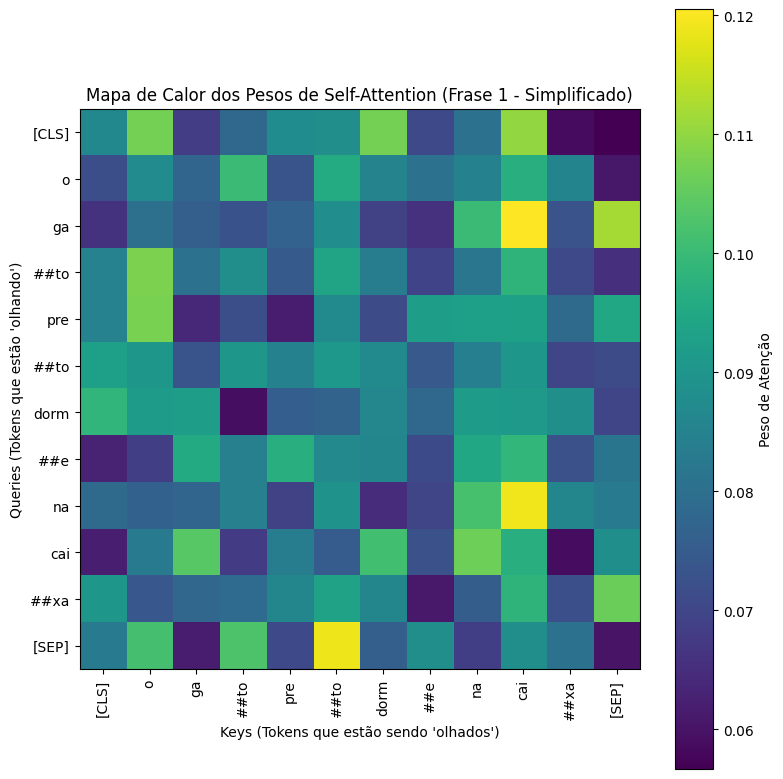

Matriz de Pesos de Atenção (Frase 1 - Simplificado - Linha = Query, Coluna = Key):
[[0.086 0.107 0.068 0.078 0.088 0.088 0.107 0.071 0.081 0.11  0.058 0.057]
 [0.072 0.087 0.077 0.1   0.073 0.096 0.085 0.081 0.085 0.097 0.085 0.061]
 [0.066 0.08  0.076 0.073 0.077 0.088 0.069 0.066 0.1   0.121 0.073 0.112]
 [0.085 0.108 0.081 0.088 0.075 0.094 0.084 0.069 0.082 0.098 0.071 0.066]
 [0.085 0.108 0.064 0.072 0.062 0.087 0.071 0.092 0.093 0.093 0.079 0.095]
 [0.093 0.09  0.073 0.09  0.085 0.091 0.087 0.074 0.084 0.091 0.07  0.071]
 [0.099 0.092 0.092 0.059 0.076 0.077 0.086 0.078 0.092 0.091 0.088 0.07 ]
 [0.063 0.069 0.096 0.084 0.097 0.087 0.086 0.071 0.095 0.099 0.072 0.081]
 [0.079 0.076 0.078 0.084 0.069 0.089 0.065 0.07  0.102 0.119 0.086 0.083]
 [0.062 0.083 0.104 0.068 0.084 0.075 0.101 0.073 0.107 0.097 0.059 0.088]
 [0.091 0.074 0.078 0.079 0.086 0.094 0.086 0.061 0.076 0.098 0.072 0.106]
 [0.083 0.102 0.062 0.103 0.071 0.119 0.076 0.088 0.068 0.088 0.081 0.06 ]]


In [113]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizar a matriz de atenção da Frase 1 (usando a camada SelfAttention simplificada)
attention_matrix1 = weights1[0].numpy() # Pega a matriz de atenção para a primeira (e única) sequência

plt.figure(figsize=(8, 8))
plt.imshow(attention_matrix1, cmap='viridis')

# Obter os tokens da frase 1 para os rótulos
tokens1 = tokenizer.convert_ids_to_tokens(inputs1['input_ids'][0].numpy())
seq_len1 = len(tokens1)

plt.xticks(ticks=np.arange(seq_len1), labels=tokens1, rotation=90)
plt.yticks(ticks=np.arange(seq_len1), labels=tokens1)
plt.xlabel("Keys (Tokens que estão sendo 'olhados')")
plt.ylabel("Queries (Tokens que estão 'olhando')")
plt.title("Mapa de Calor dos Pesos de Self-Attention (Frase 1 - Simplificado)")
plt.colorbar(label='Peso de Atenção')
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

print("Matriz de Pesos de Atenção (Frase 1 - Simplificado - Linha = Query, Coluna = Key):")
print(attention_matrix1.round(3))

/tmp/ipython-input-174898694.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta o layout para acomodar o suptitle e colorbar


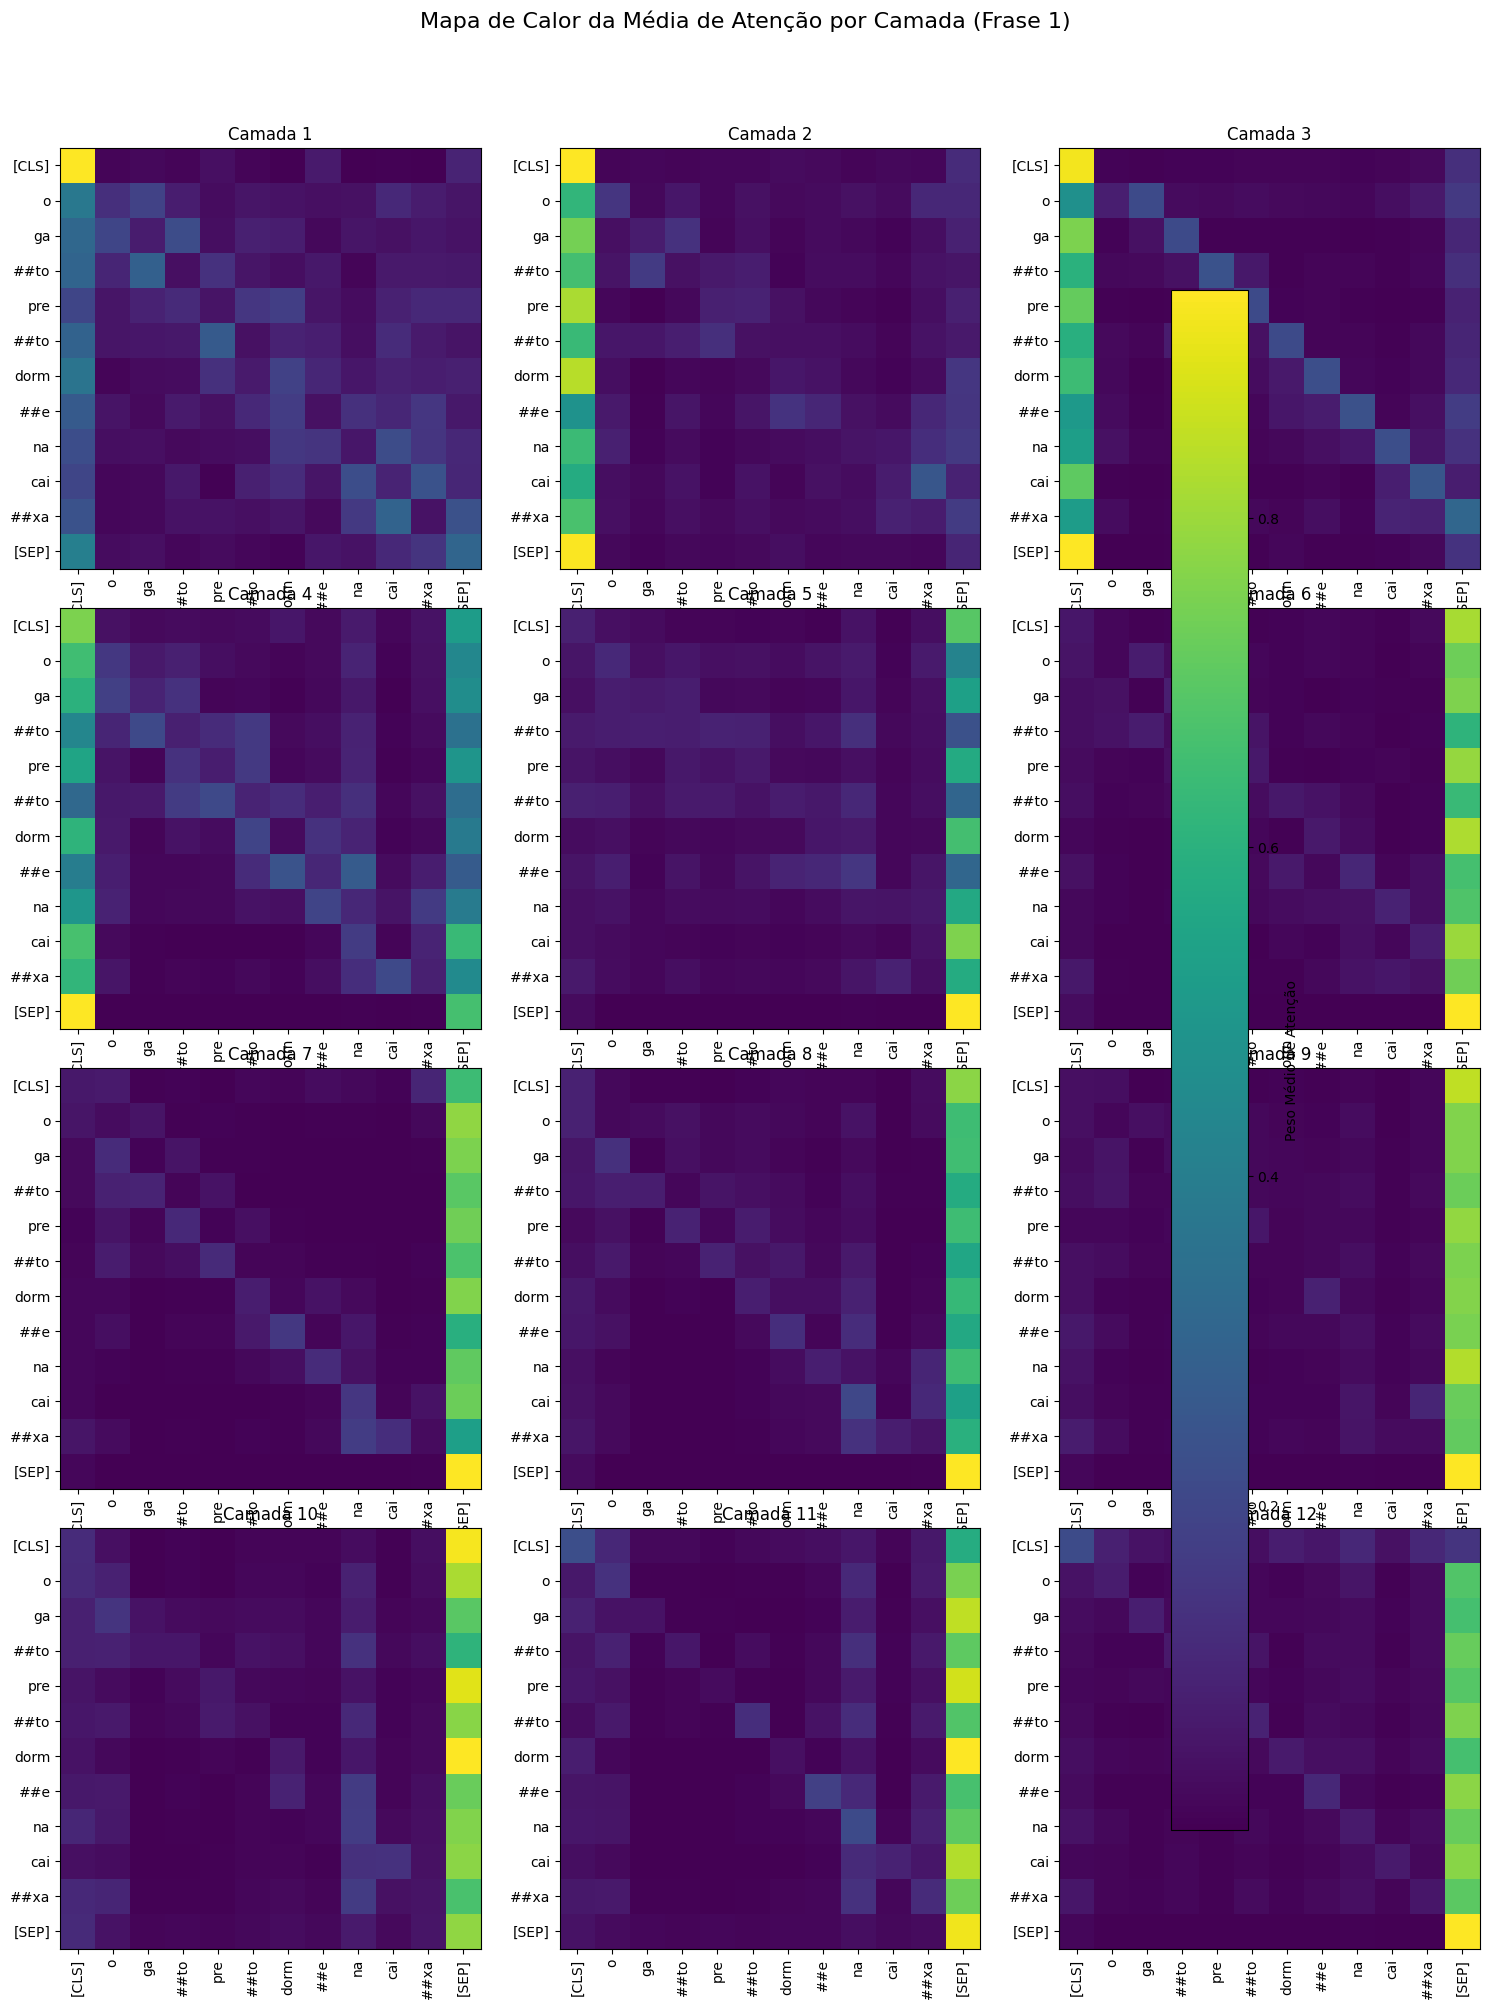

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Acessar os pesos de atenção internos da Frase 1 (obtidos na célula anterior)
# attention_weights_bert1 é uma tupla de tensores, um para cada camada
# Cada tensor tem o formato (batch_size, num_heads, seq_len, seq_len)

# Obter os tokens da frase 1 para os rótulos dos eixos
tokens1 = tokenizer.convert_ids_to_tokens(inputs1['input_ids'][0].numpy())
seq_len1 = len(tokens1)
num_layers = len(attention_weights_bert1)

# Configurar a figura e os subplots (grid de 3x4 para 12 camadas)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20)) # Ajuste o tamanho conforme necessário
axes = axes.flatten() # Achata a matriz de eixos para facilitar a iteração

# Iterar sobre cada camada para calcular a média da atenção e preparar a visualização
for i in range(num_layers):
    # Pega o tensor de atenção para a camada atual (batch_size=1)
    layer_attention = attention_weights_bert1[i][0] # Formato: (num_heads, seq_len, seq_len)

    # Calcula a média dos pesos de atenção sobre todas as cabeças
    average_attention = tf.reduce_mean(layer_attention, axis=0).numpy() # Formato: (seq_len, seq_len)

    # Gerar o heatmap no subplot correspondente
    ax = axes[i]
    im = ax.imshow(average_attention, cmap='viridis')

    # Configurar rótulos e título do subplot
    ax.set_xticks(np.arange(seq_len1))
    ax.set_yticks(np.arange(seq_len1))
    ax.set_xticklabels(tokens1, rotation=90)
    ax.set_yticklabels(tokens1)
    ax.set_title(f'Camada {i+1}')

# Adicionar uma barra de cor geral para a figura
fig.colorbar(im, ax=axes.ravel().tolist(), label='Peso Médio de Atenção')

plt.suptitle('Mapa de Calor da Média de Atenção por Camada (Frase 1)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta o layout para acomodar o suptitle e colorbar
plt.show()